# 01 — Batting Analysis
## AuctionIQ — IPL Player Valuation & Auction Intelligence
**Goal:** Calculate comprehensive batting statistics for every IPL player across all 19 seasons — strike rate, average, boundary %, consistency score, and phase-wise performance (powerplay, middle, death overs).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../screenshots', exist_ok=True)

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

# Load master data
master = pd.read_csv('../data/processed/master_balls.csv')
meta   = pd.read_csv('../data/processed/master_meta.csv')

# Focus on IPL only — exclude any non-IPL matches
master = master[master['season'].astype(str).str.len() > 0]

print(f"✅ Data loaded")
print(f"   Balls   : {len(master):,}")
print(f"   Matches : {master['match_id'].nunique():,}")
print(f"   Seasons : {sorted(master['season'].astype(str).unique())}")

✅ Data loaded
   Balls   : 287,513
   Matches : 1,209
   Seasons : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']


In [2]:
# Define over phases — critical for auction valuation
# Powerplay: 0-6, Middle: 7-15, Death: 16-20

def get_phase(ball):
    over = int(float(ball))
    if over < 6:
        return 'Powerplay'
    elif over < 15:
        return 'Middle'
    else:
        return 'Death'

master['phase'] = master['ball'].apply(get_phase)

print("Phase distribution:")
print(master['phase'].value_counts())
print(f"\nSample:")
print(master[['ball','phase']].head(10))

Phase distribution:
phase
Middle       131836
Powerplay     90341
Death         65336
Name: count, dtype: int64

Sample:
   ball      phase
0   0.1  Powerplay
1   0.2  Powerplay
2   0.3  Powerplay
3   0.4  Powerplay
4   0.5  Powerplay
5   0.6  Powerplay
6   0.7  Powerplay
7   1.1  Powerplay
8   1.2  Powerplay
9   1.3  Powerplay


In [3]:
# Filter only legal deliveries for batting stats (exclude wides)
legal = master[master['wides'].isna()].copy()

# Core batting stats per player
batting_stats = legal.groupby('striker').agg(
    innings        = ('match_id', 'nunique'),
    balls_faced    = ('ball', 'count'),
    runs_scored    = ('runs_off_bat', 'sum'),
    fours          = ('runs_off_bat', lambda x: (x == 4).sum()),
    sixes          = ('runs_off_bat', lambda x: (x == 6).sum()),
    dot_balls      = ('runs_off_bat', lambda x: (x == 0).sum()),
    dismissals     = ('player_dismissed', lambda x: x.notna().sum())
).reset_index()

# Derived metrics
batting_stats['strike_rate']    = (batting_stats['runs_scored'] / batting_stats['balls_faced'] * 100).round(2)
batting_stats['batting_avg']    = (batting_stats['runs_scored'] / batting_stats['dismissals'].replace(0, np.nan)).round(2)
batting_stats['boundary_pct']   = ((batting_stats['fours'] + batting_stats['sixes']) / batting_stats['balls_faced'] * 100).round(2)
batting_stats['dot_ball_pct']   = (batting_stats['dot_balls'] / batting_stats['balls_faced'] * 100).round(2)
batting_stats['runs_per_innings']= (batting_stats['runs_scored'] / batting_stats['innings']).round(2)

# Filter — minimum 20 innings for meaningful stats
batting_stats = batting_stats[batting_stats['innings'] >= 20].copy()

print(f"✅ Batting stats calculated")
print(f"   Players with 20+ innings: {len(batting_stats)}")
print(f"\nTop 10 by runs scored:")
print(batting_stats.nlargest(10, 'runs_scored')[
    ['striker','innings','runs_scored','strike_rate','batting_avg','boundary_pct']
].to_string(index=False))

✅ Batting stats calculated
   Players with 20+ innings: 231

Top 10 by runs scored:
       striker  innings  runs_scored  strike_rate  batting_avg  boundary_pct
       V Kohli      267         9022       133.88        38.07         16.58
     RG Sharma      270         7185       132.56        28.86         17.79
      S Dhawan      221         6769       127.09        35.07         17.29
     DA Warner      184         6567       139.66        40.04         19.12
      KL Rahul      143         5593       138.41        45.47         17.72
      SK Raina      200         5536       136.83        33.15         17.55
      MS Dhoni      241         5439       137.45        34.42         16.15
     AM Rahane      191         5194       125.31        30.02         15.83
AB de Villiers      170         5181       151.89        41.45         19.55
     SV Samson      179         5008       140.60        31.90         18.14


In [4]:
# Phase-wise stats — this is what makes AuctionIQ unique
phase_batting = legal.groupby(['striker', 'phase']).agg(
    balls_faced  = ('ball', 'count'),
    runs_scored  = ('runs_off_bat', 'sum'),
    dot_balls    = ('runs_off_bat', lambda x: (x == 0).sum()),
    fours        = ('runs_off_bat', lambda x: (x == 4).sum()),
    sixes        = ('runs_off_bat', lambda x: (x == 6).sum()),
).reset_index()

phase_batting['strike_rate']  = (phase_batting['runs_scored'] / phase_batting['balls_faced'] * 100).round(2)
phase_batting['boundary_pct'] = ((phase_batting['fours'] + phase_batting['sixes']) / phase_batting['balls_faced'] * 100).round(2)

# Pivot to wide format — one row per player
phase_pivot = phase_batting.pivot_table(
    index='striker',
    columns='phase',
    values=['strike_rate', 'boundary_pct', 'runs_scored'],
    aggfunc='first'
).round(2)

# Flatten column names
phase_pivot.columns = [f"{col[1].lower()}_{col[0]}" for col in phase_pivot.columns]
phase_pivot = phase_pivot.reset_index()

# Merge with batting stats
batting_full = batting_stats.merge(phase_pivot, on='striker', how='left')

print(f"✅ Phase-wise stats added")
print(f"   Columns now: {len(batting_full.columns)}")
print(f"\nPhase strike rates for top 5 batters:")
cols = ['striker', 'powerplay_strike_rate', 'middle_strike_rate', 'death_strike_rate']
print(batting_full.nlargest(5, 'runs_scored')[cols].to_string(index=False))

✅ Phase-wise stats added
   Columns now: 22

Phase strike rates for top 5 batters:
  striker  powerplay_strike_rate  middle_strike_rate  death_strike_rate
  V Kohli                 127.63              125.59             187.81
RG Sharma                 126.00              121.82             181.14
 S Dhawan                 122.75              126.52             158.67
DA Warner                 138.08              134.83             176.90
 KL Rahul                 128.30              137.21             178.81


In [5]:
# Consistency Score — measures how reliably a batter performs
# Uses coefficient of variation (lower CV = more consistent)

# Get per-match scores for each batter
match_scores = legal.groupby(['striker', 'match_id'])['runs_off_bat'].sum().reset_index()
match_scores.columns = ['striker', 'match_id', 'match_runs']

# Calculate consistency metrics
consistency = match_scores.groupby('striker').agg(
    mean_score  = ('match_runs', 'mean'),
    std_score   = ('match_runs', 'std'),
    median_score= ('match_runs', 'median'),
    matches_30  = ('match_runs', lambda x: (x >= 30).sum()),
    matches_50  = ('match_runs', lambda x: (x >= 50).sum()),
).reset_index()

# Consistency score — inverse of coefficient of variation (scaled 0-100)
consistency['cv'] = (consistency['std_score'] / consistency['mean_score'].replace(0, np.nan))
consistency['consistency_score'] = (1 / consistency['cv'].replace(0, np.nan) * 100).round(2)

# Merge into batting_full
batting_full = batting_full.merge(consistency, on='striker', how='left')

print(f"✅ Consistency scores added")
print(f"\nMost consistent batters (min 20 innings):")
print(batting_full.nlargest(10, 'consistency_score')[
    ['striker','innings','mean_score','consistency_score','matches_30','matches_50']
].to_string(index=False))

✅ Consistency scores added

Most consistent batters (min 20 innings):
        striker  innings  mean_score  consistency_score  matches_30  matches_50
B Sai Sudharsan       48   44.062500             151.88          32          17
  A Raghuvanshi       26   25.846154             150.44          11           4
      H Klaasen       53   34.509434             145.66          29          12
     AK Markram       63   25.920635             138.02          25          10
 A Ashish Reddy       23   12.173913             137.15           2           0
       R Dravid       82   26.512195             135.82          32          11
    Tilak Varma       58   28.965517             134.35          27           9
      R Sathish       24   11.250000             133.53           0           0
         DB Das       22   13.818182             132.23           2           0
      JP Duminy       75   27.053333             132.19          27          14


In [6]:
# Recent form — last 3 seasons weighted more than career stats
# This is critical for auction — teams buy future performance, not past glory

recent_seasons = ['2023', '2024', '2025']
recent = legal[legal['season'].astype(str).isin(recent_seasons)]

recent_form = recent.groupby('striker').agg(
    recent_innings  = ('match_id', 'nunique'),
    recent_runs     = ('runs_off_bat', 'sum'),
    recent_balls    = ('ball', 'count'),
).reset_index()

recent_form['recent_sr']  = (recent_form['recent_runs'] / recent_form['recent_balls'] * 100).round(2)
recent_form['recent_avg'] = (recent_form['recent_runs'] / recent_form['recent_innings']).round(2)

# Filter min 10 innings in recent seasons
recent_form = recent_form[recent_form['recent_innings'] >= 10]

# Merge
batting_full = batting_full.merge(recent_form, on='striker', how='left')

print(f"✅ Recent form added (2023-2025)")
print(f"   Players with 10+ recent innings: {len(recent_form)}")
print(f"\nTop 10 recent form batters:")
print(recent_form.nlargest(10, 'recent_runs')[
    ['striker','recent_innings','recent_runs','recent_sr','recent_avg']
].to_string(index=False))

✅ Recent form added (2023-2025)
   Players with 10+ recent innings: 113

Top 10 recent form batters:
        striker  recent_innings  recent_runs  recent_sr  recent_avg
        V Kohli              44         2037     146.55       46.30
   Shubman Gill              44         1966     154.80       44.68
       SA Yadav              43         1667     172.39       38.77
B Sai Sudharsan              35         1648     147.80       47.09
    YBK Jaiswal              43         1619     160.14       37.65
      H Klaasen              39         1414     173.50       36.26
       N Pooran              43         1381     183.16       32.12
   F du Plessis              38         1370     150.72       36.05
       KL Rahul              36         1340     135.76       37.22
     RD Gaikwad              34         1295     144.85       38.09


In [7]:
# Batting Performance Index — AuctionIQ's core metric
# Weighted composite score combining all batting dimensions

# Normalise each metric to 0-100 scale
def normalise(series):
    min_val = series.min()
    max_val = series.max()
    return ((series - min_val) / (max_val - min_val) * 100).round(2)

# Work on players with sufficient data
bpi_df = batting_full.dropna(subset=[
    'strike_rate', 'batting_avg', 'boundary_pct',
    'consistency_score', 'death_strike_rate'
]).copy()

# Normalise key metrics
bpi_df['n_strike_rate']      = normalise(bpi_df['strike_rate'])
bpi_df['n_batting_avg']      = normalise(bpi_df['batting_avg'].fillna(0))
bpi_df['n_boundary_pct']     = normalise(bpi_df['boundary_pct'])
bpi_df['n_consistency']      = normalise(bpi_df['consistency_score'])
bpi_df['n_death_sr']         = normalise(bpi_df['death_strike_rate'].fillna(0))
bpi_df['n_recent_sr']        = normalise(bpi_df['recent_sr'].fillna(bpi_df['strike_rate']))

# Weighted BPI — weights reflect auction priorities
# Recent form matters most, then death SR, then overall SR
bpi_df['BPI'] = (
    bpi_df['n_recent_sr']      * 0.25 +   # Recent form
    bpi_df['n_death_sr']       * 0.20 +   # Death over ability
    bpi_df['n_strike_rate']    * 0.20 +   # Career strike rate
    bpi_df['n_batting_avg']    * 0.15 +   # Consistency of scoring
    bpi_df['n_boundary_pct']   * 0.10 +   # Boundary hitting
    bpi_df['n_consistency']    * 0.10     # Match-to-match consistency
).round(2)

# Final ranking
bpi_df = bpi_df.sort_values('BPI', ascending=False).reset_index(drop=True)
bpi_df['batting_rank'] = bpi_df.index + 1

print(f"✅ Batting Performance Index (BPI) calculated")
print(f"   Players ranked: {len(bpi_df)}")
print(f"\nTop 20 Batters by BPI:")
print(bpi_df.head(20)[
    ['batting_rank','striker','innings','runs_scored',
     'strike_rate','batting_avg','consistency_score','BPI']
].to_string(index=False))

✅ Batting Performance Index (BPI) calculated
   Players ranked: 229

Top 20 Batters by BPI:
 batting_rank         striker  innings  runs_scored  strike_rate  batting_avg  consistency_score   BPI
            1       H Klaasen       53         1829       165.52        42.53             145.66 86.12
            2        TH David       51         1029       176.80        36.75             124.64 83.83
            3         PD Salt       40         1258       174.48        33.11             113.77 83.19
            4 B Sai Sudharsan       48         2115       148.32        49.19             151.88 82.92
            5      Naman Dhir       26          546       170.09        27.30             121.72 82.32
            6        T Stubbs       37          912       157.51        45.60             119.00 82.23
            7     YBK Jaiswal       75         2472       153.54        35.83             119.68 80.14
            8      AD Russell      114         2655       174.10        28.86       

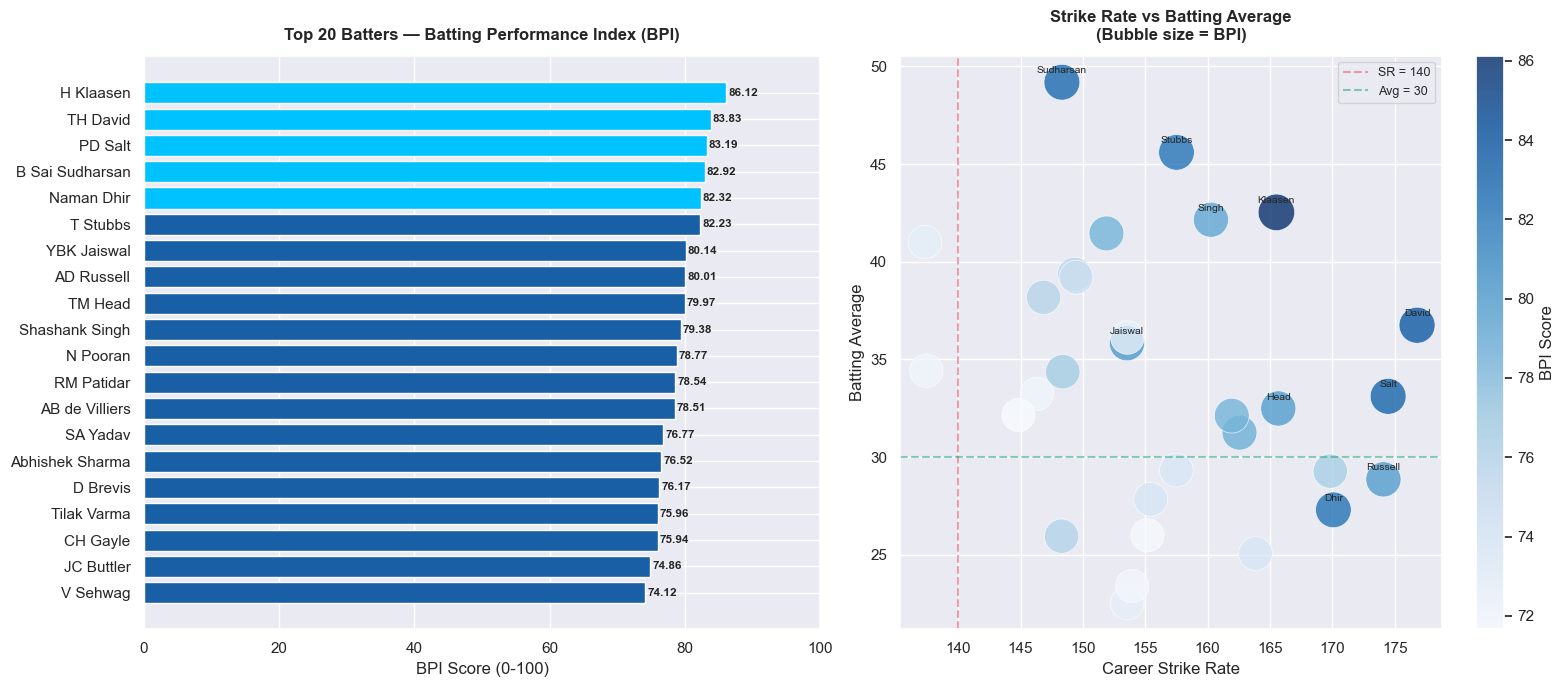

✅ Chart saved → screenshots/01_batting_bpi.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top20 = bpi_df.head(20).sort_values('BPI')
colors = ['#00C2FF' if i >= 15 else '#185FA5' for i in range(20)]

# Chart 1 — BPI Ranking
axes[0].barh(top20['striker'], top20['BPI'], color=colors)
axes[0].set_title('Top 20 Batters — Batting Performance Index (BPI)',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('BPI Score (0-100)')
for i, (val, name) in enumerate(zip(top20['BPI'], top20['striker'])):
    axes[0].text(val + 0.3, i, f'{val}', va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlim(0, 100)

# Chart 2 — Strike Rate vs Batting Avg bubble chart
scatter_df = bpi_df.head(30)
scatter = axes[1].scatter(
    scatter_df['strike_rate'],
    scatter_df['batting_avg'].fillna(0),
    s=scatter_df['BPI'] * 8,
    c=scatter_df['BPI'],
    cmap='Blues',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)
# Annotate top 10
for _, row in scatter_df.head(10).iterrows():
    axes[1].annotate(
        row['striker'].split()[-1],
        (row['strike_rate'], row['batting_avg']),
        fontsize=7.5, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )
plt.colorbar(scatter, ax=axes[1], label='BPI Score')
axes[1].set_title('Strike Rate vs Batting Average\n(Bubble size = BPI)',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Career Strike Rate')
axes[1].set_ylabel('Batting Average')
axes[1].axvline(x=140, color='#E94560', linestyle='--', alpha=0.5, label='SR = 140')
axes[1].axhline(y=30, color='#1D9E75', linestyle='--', alpha=0.5, label='Avg = 30')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../screenshots/01_batting_bpi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/01_batting_bpi.png")

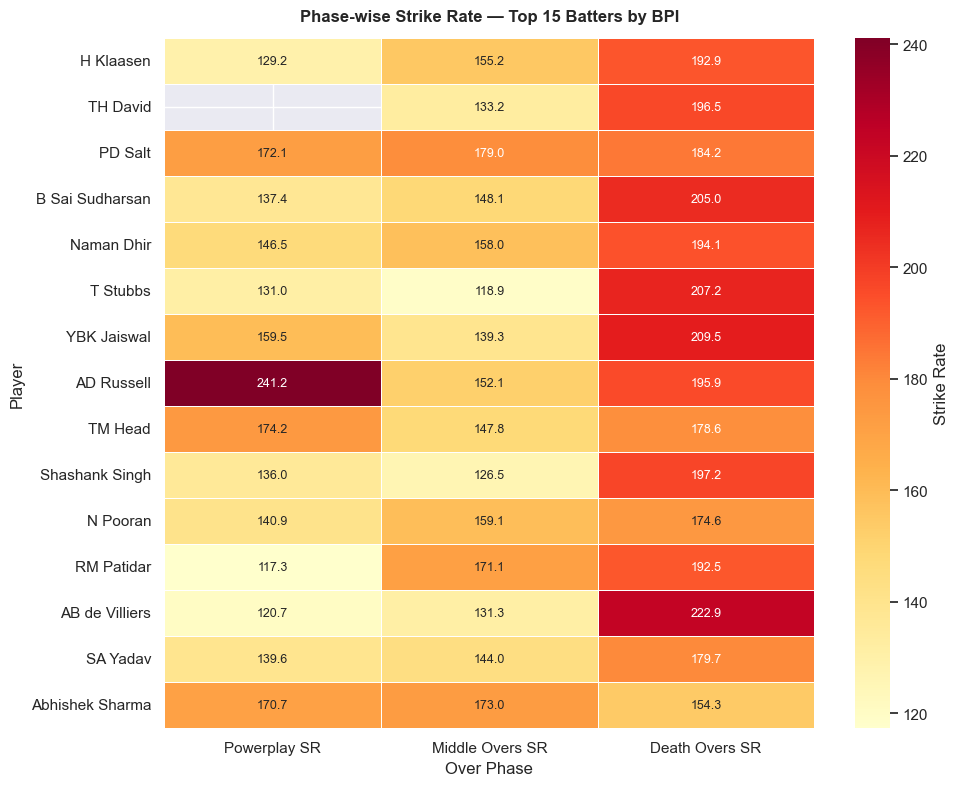

✅ Chart saved → screenshots/02_phase_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Get top 15 by BPI
top15 = bpi_df.head(15)['striker'].tolist()

# Build heatmap data
heatmap_data = bpi_df[bpi_df['striker'].isin(top15)].set_index('striker')[
    ['powerplay_strike_rate', 'middle_strike_rate', 'death_strike_rate']
].rename(columns={
    'powerplay_strike_rate': 'Powerplay SR',
    'middle_strike_rate'   : 'Middle Overs SR',
    'death_strike_rate'    : 'Death Overs SR'
})

heatmap_data = heatmap_data.reindex(top15)

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Strike Rate'}
)

ax.set_title('Phase-wise Strike Rate — Top 15 Batters by BPI',
             fontweight='bold', pad=12)
ax.set_xlabel('Over Phase')
ax.set_ylabel('Player')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/02_phase_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/02_phase_heatmap.png")

In [10]:
# Export full batting stats for Power BI and Player Index notebook
batting_export = bpi_df[[
    'batting_rank', 'striker', 'innings', 'balls_faced',
    'runs_scored', 'fours', 'sixes', 'dismissals',
    'strike_rate', 'batting_avg', 'boundary_pct', 'dot_ball_pct',
    'runs_per_innings', 'consistency_score', 'matches_30', 'matches_50',
    'powerplay_strike_rate', 'middle_strike_rate', 'death_strike_rate',
    'recent_innings', 'recent_runs', 'recent_sr', 'recent_avg',
    'BPI'
]].copy()

batting_export.to_csv('../data/processed/batting_stats.csv', index=False)

print(f"✅ Batting stats exported → data/processed/batting_stats.csv")
print(f"   Players : {len(batting_export)}")
print(f"   Columns : {len(batting_export.columns)}")
print(f"\nNext → 02_bowling_analysis.ipynb")

✅ Batting stats exported → data/processed/batting_stats.csv
   Players : 229
   Columns : 24

Next → 02_bowling_analysis.ipynb
